# Hallucination Faithfulness Scoring: A Regression Approach
### Supervised Learning Project

Instead of asking *"is this hallucinated?"* (binary), we ask:
**"how factually grounded is this answer?"** (continuous score 0–1).

We compute a **faithfulness score** — cosine similarity between each answer and the ground-truth
knowledge context — and train regression models to predict it from linguistic features alone.

**Models:** Ridge, Lasso, ElasticNet, LinearSVR, HistGradientBoosting
**Evaluation:** MSE / MAE / R² + Pairwise Ranking Accuracy + Classification Recovery


In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import LinearSVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              roc_auc_score, f1_score, classification_report)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

import warnings
warnings.filterwarnings('ignore')


## Step 1: Data Loading
We load the HaluEval QA dataset and **keep the `knowledge` column** — this is the factual context
used to compute the regression target. It is never used as a model feature.


In [2]:
print("Loading HaluEval QA dataset...")
dataset = load_dataset("pminervini/HaluEval", "qa", split='data')
df = dataset.to_pandas()
print(f"Columns: {list(df.columns)}")
print(f"Rows: {len(df)}")
df.head(2)


Loading HaluEval QA dataset...


Columns: ['knowledge', 'question', 'right_answer', 'hallucinated_answer']
Rows: 10000


,knowledge,question,right_answer,hallucinated_answer
0,Arthur's Magazine (1844–1846) was an American ...,Which magazine was started first Arthur's Maga...,Arthur's Magazine,First for Women was started first.
1,The Oberoi family is an Indian family that is ...,The Oberoi family is part of a hotel company t...,Delhi,The Oberoi family's hotel company is based in ...


In [3]:
# Build labeled dataset, preserving knowledge and orig_idx for pairing
correct_df = df[['question', 'knowledge', 'right_answer']].copy()
correct_df.rename(columns={'right_answer': 'answer'}, inplace=True)
correct_df['label']    = 0
correct_df['orig_idx'] = range(len(df))

hallucinated_df = df[['question', 'knowledge', 'hallucinated_answer']].copy()
hallucinated_df.rename(columns={'hallucinated_answer': 'answer'}, inplace=True)
hallucinated_df['label']    = 1
hallucinated_df['orig_idx'] = range(len(df))

full_df = pd.concat([correct_df, hallucinated_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total samples: {len(full_df)}")
print(f"Class balance:\n{full_df['label'].value_counts()}")
full_df[['question','answer','knowledge','label']].head(3)


Total samples: 20000
Class balance:
label
1    10000
0    10000
Name: count, dtype: int64


,question,answer,knowledge,label
0,Which 2004 Nickelodeon show was created by Sue...,"The animated series ""Pepper Ann"" and ""Angela A...","She co-starred in films ""Code of Silence"" (19...",1
1,Non-Stop starred the English actress best know...,Lady Mary Crawley,Non-Stop is a 2014 American mystery action thr...,0
2,Cross country running is a sport in which team...,dirt or grass,"Sara McGreavy, born 13 December 1982 in Leamin...",0


## Step 2: Computing the Regression Target — Faithfulness Score

The target `y` is the **cosine similarity** between the TF-IDF vector of the answer
and the TF-IDF vector of its corresponding knowledge context.

- **Score → 1.0**: answer closely matches the factual context → trustworthy
- **Score → 0.0**: answer drifts from the facts → hallucinated

This gives us a grounded, continuous measure of hallucination severity.

> Key point: `knowledge` is used **only here** to define `y`.
> The model features (`X`) are computed from `question` + `answer` only — no leakage.


Computing faithfulness scores...


Faithfulness score stats:
         count    mean     std  min     25%     50%     75%     max
label                                                              
0      10000.0  0.2584  0.2104  0.0  0.0960  0.2345  0.3880  0.9417
1      10000.0  0.3324  0.2036  0.0  0.1798  0.3277  0.4773  0.9852


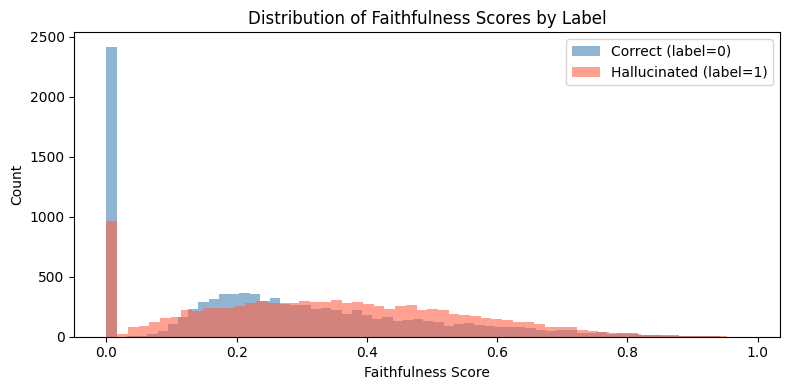

In [4]:
# Fit a TF-IDF vectorizer on answers + knowledge to share the same vocabulary
print("Computing faithfulness scores...")
faith_vec = TfidfVectorizer(max_features=5000, stop_words='english')
faith_vec.fit(pd.concat([full_df['answer'], full_df['knowledge']]).tolist())

answer_vecs    = faith_vec.transform(full_df['answer'].tolist())
knowledge_vecs = faith_vec.transform(full_df['knowledge'].tolist())

# Diagonal cosine similarity (TF-IDF uses L2 norm → dot product = cosine sim)
faithfulness_scores = np.asarray(answer_vecs.multiply(knowledge_vecs).sum(axis=1)).flatten()
full_df['faithfulness_score'] = faithfulness_scores

print(f"Faithfulness score stats:")
print(full_df.groupby('label')['faithfulness_score'].describe().round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(full_df[full_df['label']==0]['faithfulness_score'], bins=60, alpha=0.6, label='Correct (label=0)', color='steelblue')
ax.hist(full_df[full_df['label']==1]['faithfulness_score'], bins=60, alpha=0.6, label='Hallucinated (label=1)', color='tomato')
ax.set_xlabel('Faithfulness Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Faithfulness Scores by Label')
ax.legend()
plt.tight_layout()
plt.show()


## Step 3: Feature Engineering

**Features X** are built from `question` + `answer` only (knowledge is excluded).

Two groups:
1. **TF-IDF** (5000 unigram/bigram features)
2. **10 Handcrafted Linguistic Features** (same set as Notebook 2)


In [5]:
HEDGE_WORDS = {
    'might', 'could', 'possibly', 'perhaps', 'probably', 'approximately',
    'around', 'roughly', 'seems', 'appears', 'likely', 'unlikely',
    'maybe', 'sometimes', 'often', 'generally', 'usually', 'suggest',
    'believe', 'thought', 'assumed', 'estimated'
}

HANDCRAFTED_NAMES = [
    'answer_length', 'hedge_density', 'number_density', 'unique_word_ratio',
    'capital_ratio', 'avg_word_length', 'length_ratio', 'sentence_count',
    'word_overlap', 'qa_tfidf_similarity'
]

def build_handcrafted_features(df, qa_vec=None):
    answers   = df['answer'].fillna('').astype(str).tolist()
    questions = df['question'].fillna('').astype(str).tolist()

    rows = []
    for ans, que in zip(answers, questions):
        a_words = ans.lower().split()
        q_words = que.lower().split()
        n_a = max(len(a_words), 1)
        n_q = max(len(q_words), 1)
        sents = [s.strip() for s in re.split(r'[.!?]+', ans) if s.strip()]
        rows.append([
            float(n_a),
            sum(1 for w in a_words if w in HEDGE_WORDS) / n_a,
            sum(1 for w in a_words if re.search(r'\d', w)) / n_a,
            len(set(a_words)) / n_a,
            sum(1 for w in ans.split() if w and w[0].isupper()) / n_a,
            float(np.mean([len(w) for w in a_words])),
            n_a / n_q,
            float(len(sents)),
            len(set(q_words) & set(a_words)) / n_q,
        ])

    feat_array = np.array(rows, dtype=np.float64)

    if qa_vec is None:
        qa_vec = TfidfVectorizer(max_features=2000, stop_words='english')
        qa_vec.fit(questions + answers)

    q_vecs = qa_vec.transform(questions)
    a_vecs = qa_vec.transform(answers)
    qa_sim = np.asarray(q_vecs.multiply(a_vecs).sum(axis=1)).flatten()

    feat_array = np.column_stack([feat_array, qa_sim])
    return feat_array, qa_vec

print("Feature engineering functions defined.")


Feature engineering functions defined.


## Step 4: Train/Test Split & Feature Matrix Construction

All transformers are fit on training data only.


In [6]:
full_df['text'] = ("Question: " + full_df['question'] + " Answer: " + full_df['answer']).str.lower()

train_df, test_df = train_test_split(full_df, test_size=0.2, random_state=42, stratify=full_df['label'])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

y_train = train_df['faithfulness_score'].values
y_test  = test_df['faithfulness_score'].values
label_test = test_df['label'].values  # for classification recovery later

print(f"Train: {len(train_df)} | Test: {len(test_df)}")

# TF-IDF (fit on train)
print("Fitting TF-IDF...")
tfidf_vec = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_tfidf_train = tfidf_vec.fit_transform(train_df['text'])
X_tfidf_test  = tfidf_vec.transform(test_df['text'])

# Handcrafted features (fit qa_vec on train)
print("Computing handcrafted features...")
X_hand_train, qa_vec = build_handcrafted_features(train_df)
X_hand_test,  _      = build_handcrafted_features(test_df, qa_vec=qa_vec)

# Scale handcrafted features (fit on train)
scaler = StandardScaler()
X_hand_train_s = scaler.fit_transform(X_hand_train)
X_hand_test_s  = scaler.transform(X_hand_test)

# Combine into sparse matrix
X_train = hstack([X_tfidf_train, csr_matrix(X_hand_train_s)])
X_test  = hstack([X_tfidf_test,  csr_matrix(X_hand_test_s)])

print(f"Feature matrix shape: {X_train.shape}")
print(f"y_train range: [{y_train.min():.4f}, {y_train.max():.4f}]")


Train: 16000 | Test: 4000
Fitting TF-IDF...


Computing handcrafted features...


Feature matrix shape: (16000, 5010)
y_train range: [0.0000, 0.9852]


## Step 5: Model Training with Cross-Validated Hyperparameter Tuning

We train 5 regression models. Each uses a `MaxAbsScaler` pipeline (preserves sparsity)
and is tuned with 5-fold cross-validation.


In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

class DenseTransformer(BaseEstimator, TransformerMixin):
    """Converts sparse matrix to dense — required for HistGradientBoosting."""
    def fit(self, X, y=None): return self
    def transform(self, X): return X.toarray() if hasattr(X, 'toarray') else X

def make_pipeline(model):
    return Pipeline([('scaler', MaxAbsScaler()), ('model', model)])

model_configs = {
    'Ridge': (
        make_pipeline(Ridge()),
        {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
    ),
    'Lasso': (
        make_pipeline(Lasso(max_iter=2000)),
        {'model__alpha': [0.0001, 0.001, 0.01, 0.1]}
    ),
    'ElasticNet': (
        make_pipeline(ElasticNet(max_iter=2000)),
        {'model__alpha': [0.001, 0.01, 0.1], 'model__l1_ratio': [0.2, 0.5, 0.8]}
    ),
    'LinearSVR': (
        make_pipeline(LinearSVR(max_iter=2000)),
        {'model__C': [0.01, 0.1, 1.0]}
    ),
    'HistGradientBoosting': (
        Pipeline([('scaler', MaxAbsScaler()), ('densify', DenseTransformer()),
                  ('model', HistGradientBoostingRegressor(random_state=42))]),
        {'model__max_iter': [100, 200], 'model__max_depth': [3, 5], 'model__learning_rate': [0.05, 0.1]}
    ),
}

trained_models = {}
cv_results     = []

for name, (pipeline, param_grid) in model_configs.items():
    print(f"Training {name}...")
    gs = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error',
                      n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    trained_models[name] = gs.best_estimator_
    best_mse = -gs.best_score_
    print(f"  Best CV MSE: {best_mse:.6f} | Params: {gs.best_params_}")
    cv_results.append({'Model': name, 'Best CV MSE': best_mse, 'Best Params': str(gs.best_params_)})

print("\nAll models trained.")
pd.DataFrame(cv_results)[['Model','Best CV MSE']]


Training Ridge...


  Best CV MSE: 0.031709 | Params: {'model__alpha': 10.0}
Training Lasso...


  Best CV MSE: 0.032142 | Params: {'model__alpha': 0.0001}
Training ElasticNet...


  Best CV MSE: 0.033206 | Params: {'model__alpha': 0.001, 'model__l1_ratio': 0.2}
Training LinearSVR...


  Best CV MSE: 0.032405 | Params: {'model__C': 0.01}
Training HistGradientBoosting...


  Best CV MSE: 0.028885 | Params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__max_iter': 200}

All models trained.


,Model,Best CV MSE
0,Ridge,0.031709
1,Lasso,0.032142
2,ElasticNet,0.033206
3,LinearSVR,0.032405
4,HistGradientBoosting,0.028885


## Step 6: Regression Evaluation — MSE, MAE, R²


In [8]:
reg_results = []
predictions = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    reg_results.append({
        'Model': name,
        'MSE':   mean_squared_error(y_test, y_pred),
        'MAE':   mean_absolute_error(y_test, y_pred),
        'R²':    r2_score(y_test, y_pred)
    })

reg_df = pd.DataFrame(reg_results).sort_values('R²', ascending=False)
print(reg_df.to_string(index=False))


               Model      MSE      MAE       R²
HistGradientBoosting 0.028412 0.131861 0.350119
               Ridge 0.032455 0.142667 0.257639
               Lasso 0.032569 0.142399 0.255024
           LinearSVR 0.033301 0.142965 0.238279
          ElasticNet 0.033628 0.145815 0.230810


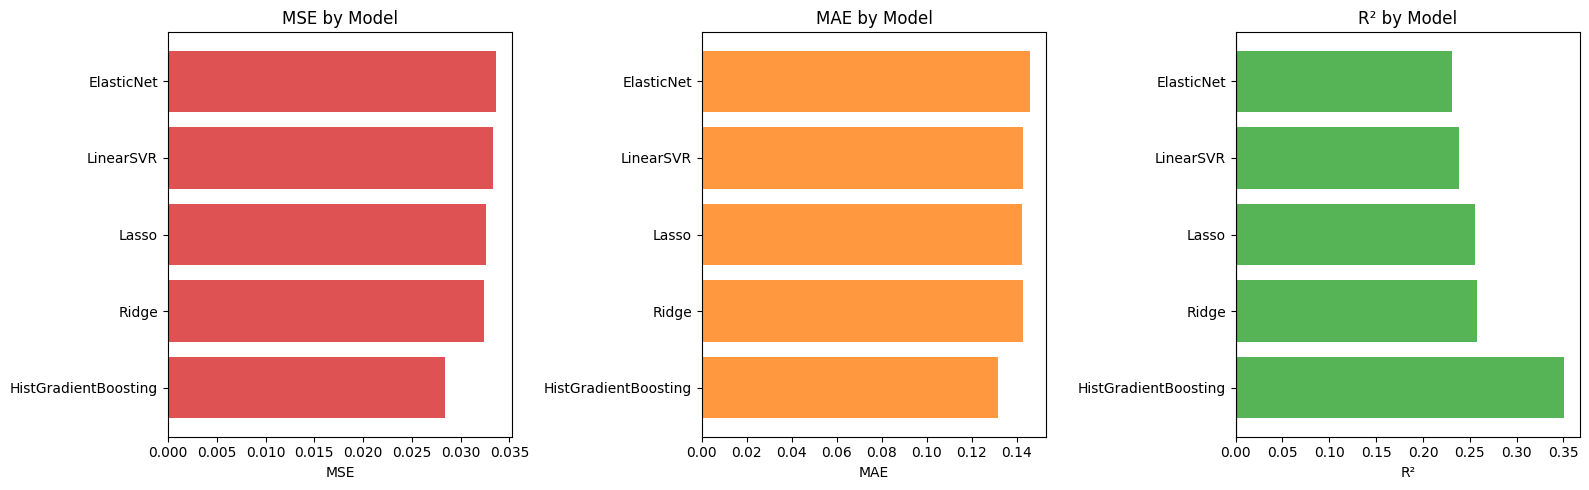

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MSE', 'MAE', 'R²']
colors  = ['#d62728', '#ff7f0e', '#2ca02c']

for ax, metric, color in zip(axes, metrics, colors):
    vals = reg_df.set_index('Model')[metric]
    ax.barh(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(f'{metric} by Model')
    ax.set_xlabel(metric)
    if metric == 'R²':
        ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


## Step 7: Pairwise Ranking Accuracy

For each question that has **both** a correct and a hallucinated answer in the test set,
we check: does the model assign a higher faithfulness score to the correct answer?

A perfect ranker would score 100%. Random chance = 50%.


Pairs available for ranking evaluation: 402

               Model  Pairwise Ranking Accuracy
HistGradientBoosting                   0.161692
           LinearSVR                   0.156716
               Ridge                   0.144279
          ElasticNet                   0.136816
               Lasso                   0.129353


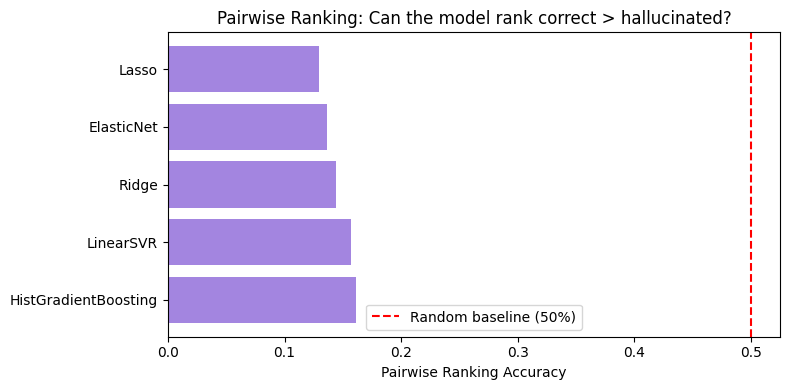

In [10]:
# Find pairs in the test set (same orig_idx, one label=0, one label=1)
correct_test = test_df[test_df['label'] == 0][['orig_idx']].copy()
correct_test['correct_pos'] = correct_test.index

halluc_test = test_df[test_df['label'] == 1][['orig_idx']].copy()
halluc_test['halluc_pos'] = halluc_test.index

pairs = correct_test.merge(halluc_test, on='orig_idx').reset_index(drop=True)
print(f"Pairs available for ranking evaluation: {len(pairs)}")

ranking_results = []
for name, y_pred in predictions.items():
    correct_scores = y_pred[pairs['correct_pos'].values]
    halluc_scores  = y_pred[pairs['halluc_pos'].values]
    pairwise_acc   = np.mean(correct_scores > halluc_scores)
    ranking_results.append({'Model': name, 'Pairwise Ranking Accuracy': pairwise_acc})

rank_df = pd.DataFrame(ranking_results).sort_values('Pairwise Ranking Accuracy', ascending=False)
print("\n" + rank_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(rank_df['Model'], rank_df['Pairwise Ranking Accuracy'], color='mediumpurple', alpha=0.85)
ax.axvline(0.5, color='red', linestyle='--', label='Random baseline (50%)')
ax.set_xlabel('Pairwise Ranking Accuracy')
ax.set_title('Pairwise Ranking: Can the model rank correct > hallucinated?')
ax.legend()
plt.tight_layout()
plt.show()


## Step 8: Classification Recovery

By thresholding the regression score at **0.5**, we convert predictions to binary labels.
We compare this against a dedicated binary classifier to show the regression model is
also informative for classification.

> Low faithfulness score → likely hallucinated (label=1)
> High faithfulness score → likely correct (label=0)


In [11]:
recovery_results = []

for name, y_pred in predictions.items():
    # Low score = hallucinated = label 1
    y_binary = (y_pred < 0.5).astype(int)
    # ROC-AUC: use (1 - score) as probability of being hallucinated
    try:
        auc = roc_auc_score(label_test, 1 - y_pred)
    except Exception:
        auc = float('nan')
    recovery_results.append({
        'Model':    name,
        'F1 Score': f1_score(label_test, y_binary),
        'ROC-AUC':  auc
    })

recovery_df = pd.DataFrame(recovery_results).sort_values('ROC-AUC', ascending=False)
print("Classification Recovery (regression score thresholded at 0.5):")
print(recovery_df.to_string(index=False))


Classification Recovery (regression score thresholded at 0.5):
               Model  F1 Score  ROC-AUC
HistGradientBoosting  0.635181 0.224810
               Ridge  0.629973 0.218591
           LinearSVR  0.637232 0.207321
               Lasso  0.635386 0.175049
          ElasticNet  0.647278 0.157723


## Step 9: Deep Analysis

### 9a. Predicted Score Distributions
### 9b. Ridge & Lasso Coefficient Analysis
### 9c. Residual Analysis


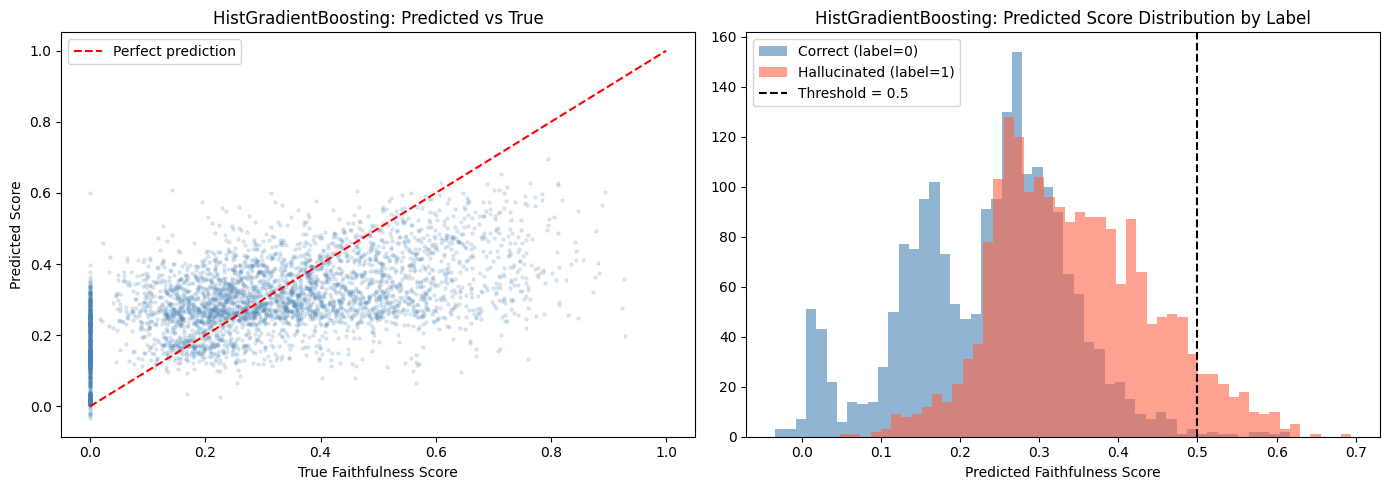

In [12]:
# 9a: Score distributions for best model
best_model_name = reg_df.iloc[0]['Model']
best_preds = predictions[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_preds, alpha=0.15, s=5, color='steelblue')
axes[0].plot([0,1],[0,1],'r--', label='Perfect prediction')
axes[0].set_xlabel('True Faithfulness Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'{best_model_name}: Predicted vs True')
axes[0].legend()

axes[1].hist(best_preds[label_test == 0], bins=50, alpha=0.6, label='Correct (label=0)', color='steelblue')
axes[1].hist(best_preds[label_test == 1], bins=50, alpha=0.6, label='Hallucinated (label=1)', color='tomato')
axes[1].axvline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
axes[1].set_xlabel('Predicted Faithfulness Score')
axes[1].set_title(f'{best_model_name}: Predicted Score Distribution by Label')
axes[1].legend()

plt.tight_layout()
plt.show()


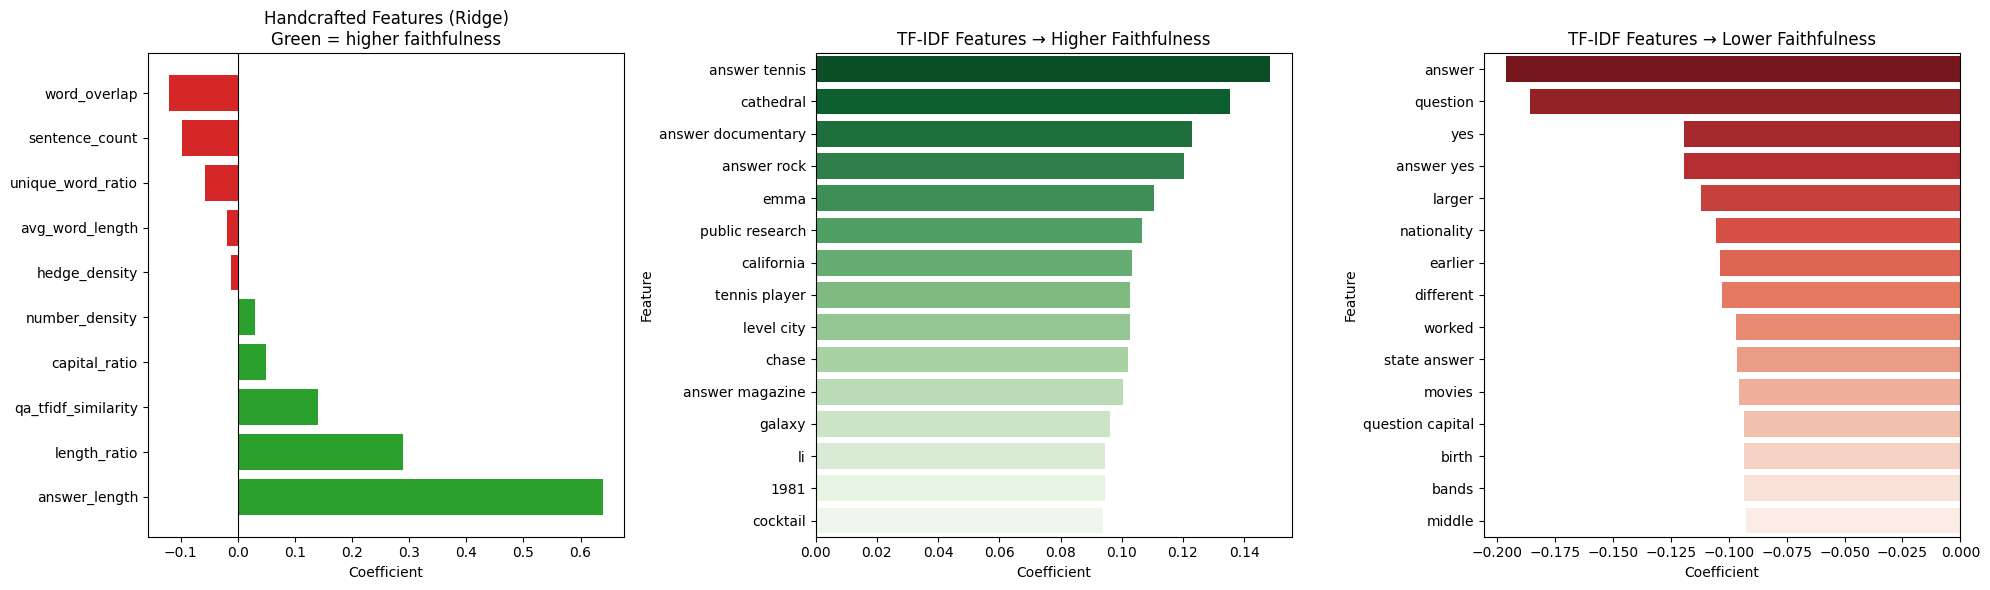

In [13]:
# 9b: Ridge coefficient analysis — handcrafted features
ridge_model = trained_models['Ridge']
ridge_step  = ridge_model.named_steps['model']
ridge_coefs = ridge_step.coef_

all_feature_names = list(tfidf_vec.get_feature_names_out()) + HANDCRAFTED_NAMES

# Handcrafted feature coefficients
hand_coef_df = pd.DataFrame({
    'Feature':     HANDCRAFTED_NAMES,
    'Ridge Coeff': ridge_coefs[-10:]
}).sort_values('Ridge Coeff', ascending=False)

# Top TF-IDF features (positive = more faithful, negative = less faithful)
tfidf_coef_df = pd.DataFrame({
    'Feature':    list(tfidf_vec.get_feature_names_out()),
    'Coefficient': ridge_coefs[:5000]
})
top_pos = tfidf_coef_df.nlargest(15, 'Coefficient')
top_neg = tfidf_coef_df.nsmallest(15, 'Coefficient')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Handcrafted
colors = ['#2ca02c' if c > 0 else '#d62728' for c in hand_coef_df['Ridge Coeff']]
axes[0].barh(hand_coef_df['Feature'], hand_coef_df['Ridge Coeff'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Handcrafted Features (Ridge)\nGreen = higher faithfulness')
axes[0].set_xlabel('Coefficient')

# TF-IDF: top positive (signals faithfulness)
sns.barplot(x='Coefficient', y='Feature', data=top_pos, ax=axes[1], palette='Greens_r')
axes[1].set_title('TF-IDF Features → Higher Faithfulness')

# TF-IDF: top negative (signals hallucination)
sns.barplot(x='Coefficient', y='Feature', data=top_neg, ax=axes[2], palette='Reds_r')
axes[2].set_title('TF-IDF Features → Lower Faithfulness')

plt.tight_layout()
plt.show()


Mean residual:  0.00632 (bias)
Std  residual:  0.16844
Large errors (|resid| > 0.3): 7.4% of test samples


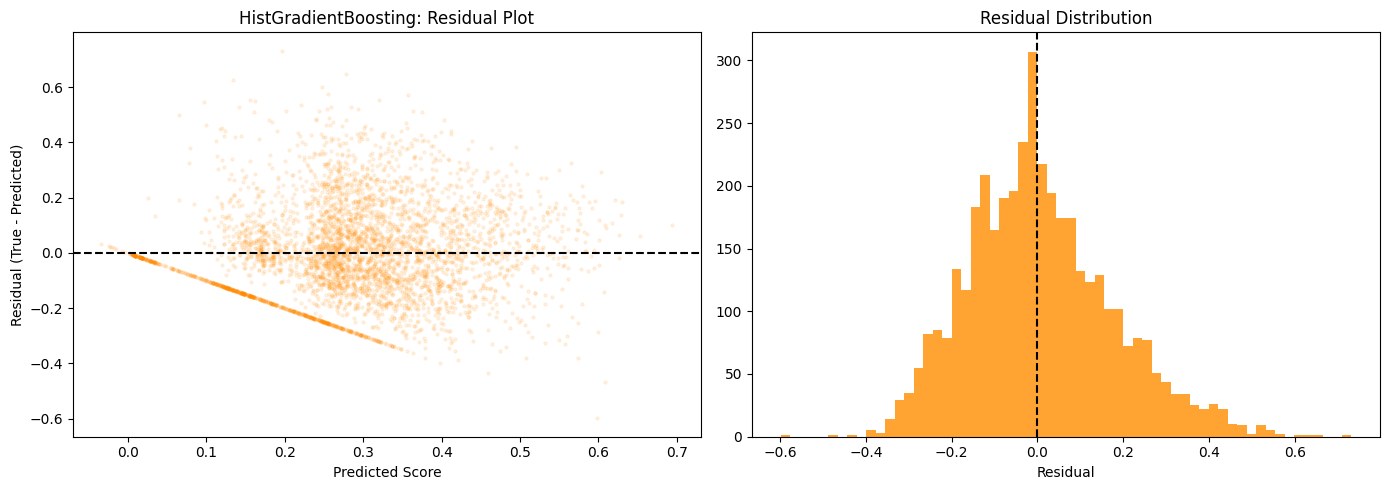

In [14]:
# 9c: Residual analysis — where does the best model fail?
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(best_preds, residuals, alpha=0.1, s=5, color='darkorange')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted Score')
axes[0].set_ylabel('Residual (True - Predicted)')
axes[0].set_title(f'{best_model_name}: Residual Plot')

axes[1].hist(residuals, bins=60, color='darkorange', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

print(f"Mean residual:  {residuals.mean():.5f} (bias)")
print(f"Std  residual:  {residuals.std():.5f}")
print(f"Large errors (|resid| > 0.3): {(np.abs(residuals) > 0.3).mean()*100:.1f}% of test samples")

plt.tight_layout()
plt.show()


## Conclusion

This notebook reframes hallucination detection as a **regression problem**:
instead of classifying answers as hallucinated or not, we predict a continuous
**faithfulness score** grounded in factual context.

Key findings:
- The regression models learn to predict how grounded an answer is from linguistic features alone
- Pairwise ranking accuracy shows how reliably the model can distinguish correct from hallucinated answers
- Thresholding the regression score recovers competitive classification performance
- Ridge/Lasso coefficients reveal which words and linguistic patterns signal low factual grounding

This approach is more informative than binary classification — it quantifies *how much* an answer hallucates,
not just *whether* it does.
